
Number of bits :  4

User input basis state to circuit :  1001


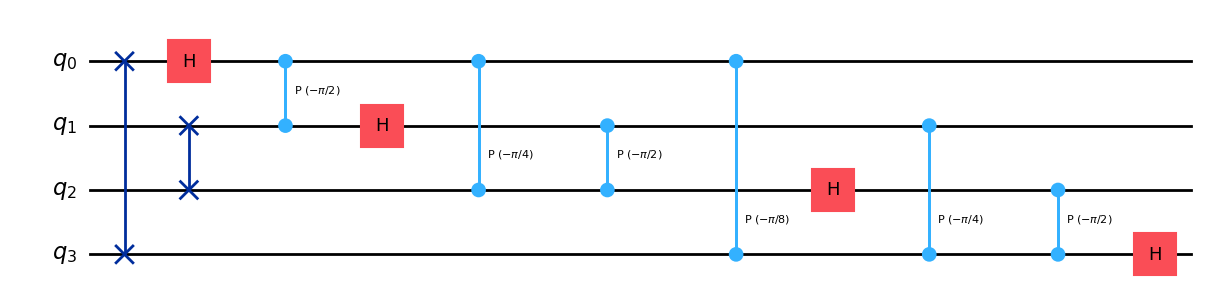


Initial Statevector:


<IPython.core.display.Latex object>


Final Statevector:


<IPython.core.display.Latex object>

In [1]:
from qiskit import QuantumRegister, QuantumCircuit
from qiskit.quantum_info import Statevector
from numpy import pi
from IPython.display import display

bits_no = int(input("Enter the number of bits: "))
secret_string = list(str(input("Enter your basis state in 0s and 1s: ")))

print("\nNumber of bits : ", bits_no)
print("\nUser input basis state to circuit : ", ''.join(secret_string))

N = 2**bits_no

# Building the inverse QFT circuit
q_reg = QuantumRegister(bits_no, "q")
circuit_1 = QuantumCircuit(q_reg)

# First SWAP part for inverse QFT
for i in range(bits_no // 2):
    circuit_1.swap(q_reg[i], q_reg[bits_no - i - 1])

# Inverse QFT main part
for i in range(bits_no):
    p = i

    for j in range(p):
        circuit_1.cp(
            -2*pi/(2**(p - j + 1)),
            q_reg[j],
            q_reg[p]
        )

    circuit_1.h(q_reg[p])

# Initialize user input as initial statevector
initial_state = Statevector.from_label(''.join(secret_string))

display(circuit_1.draw(output="mpl"))

print("\nInitial Statevector:")
display(initial_state.draw("latex"))

# Evolve statevector through inverse QFT circuit
final_state = initial_state.evolve(circuit_1)

print("\nFinal Statevector:")
display(final_state.draw("latex"))